In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

#### Nettoyage du dataframe

In [2]:
df = pd.read_csv("../data/credit_risk_dataset.csv", sep=',')
# On écarte les individus âgés de plus de 100 ans
df = df[df["person_age"]<=100]
# On écarte les individus qui ont une durée d'emploi <= 41 ans
df = df[(df["person_emp_length"]<=41)|(df["person_emp_length"].isna())]
# les person_emp_length > 41 ans sont au nombre de 2 et ont 123 ans de durée de travail (ce qui est anormal)

In [3]:
column_num = df.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df.select_dtypes(include=['object']).columns.drop('loan_grade')

In [ ]:
for col in column_num:
    plt.figure()
    df[df['loan_status']==0][col].plot(kind='density', label='Non défaut')
    df[df['loan_status']==1][col].plot(kind='density', label='défaut')
    plt.title(f'Densité de {col} selon la classe cible')
    plt.xlabel(col)
    plt.legend()
    plt.show()

In [4]:
ks_results = []

for col in column_num:
    # Séparer les groupes
    data0 = df[df['loan_status'] == 0][col].dropna()
    data1 = df[df['loan_status'] == 1][col].dropna()
    
    # Test KS
    stat, p_value = ks_2samp(data0, data1)
    
    ks_results.append({
        'variable': col,
        'KS_stat': stat,
        'p_value': p_value
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='KS_stat', ascending=False)
print(ks_df)

## Les distributions ne sont pas indentiques (p_value < 0,05)

                     variable   KS_stat       p_value
5         loan_percent_income  0.351535  0.000000e+00
4               loan_int_rate  0.335609  0.000000e+00
1               person_income  0.280457  0.000000e+00
3                   loan_amnt  0.116821  1.617359e-66
2           person_emp_length  0.111786  9.660752e-59
0                  person_age  0.034802  2.784286e-06
6  cb_person_cred_hist_length  0.029066  1.640317e-04


## SPLIT_TRAIN_TEST

- On crée un Train et un Test set : En stratifiant selon les variables catégorielles et la variables cible

In [5]:
# On crée la variable de stratification en concatenant les colonnes des variables catégorielle
# On s'assure aussi que ce soit stratifié selon la variable cible
df['label_loan_status'] = df['loan_status'].astype('category')
df["stratify_col"] = df["label_loan_status"].astype(str) + "_" + df["person_home_ownership"].astype(str) + "_" + df["loan_intent"].astype(str) + "_" + df["cb_person_default_on_file"].astype(str)
df = df.drop(columns=["label_loan_status"])

In [6]:
# On regroupe les labels rares (qui on qu'une seule modalité) ensemble, pour pouvoir spliter
counts = df["stratify_col"].value_counts()
rare_labels = counts[counts < 2].index
df["stratify_col"] = df["stratify_col"].replace(rare_labels, "Other")

In [7]:
# On split en Train_set et Test_set
df_train_set, df_test_set = train_test_split(df, test_size=0.2, stratify=df["stratify_col"], random_state=42)
df_train_set = df_train_set.drop(columns=["stratify_col"])
df_test_set = df_test_set.drop(columns=["stratify_col"])

In [16]:
# print((df_train_set["loan_status"].value_counts())/len(df_train_set))
# print((df_test_set["loan_status"].value_counts())/len(df_test_set))
# (df["loan_status"].value_counts())/len(df)

## Exploration de la base de donnée

In [8]:
column_num = df_train_set.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df_train_set.select_dtypes(include=['object']).columns.drop('loan_grade')
df_train_set.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,26059.000000,2.605900e+04,25346.000000,26059.000000,23575.000000,26059.000000,26059.000000,26059.000000
mean,27.719368,6.591008e+04,4.778663,9620.019955,11.015313,0.218197,0.170618,5.808857
std,6.193619,5.182004e+04,4.018198,6360.799611,3.236190,0.413030,0.106805,4.047377
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.840000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,1.900000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
# df_train_set_del_missing_variable = df_train_set[(~df_train_set['loan_int_rate'].isna())&(~df_train_set['person_emp_length'].isna())].copy()
# df_train_set_del_loan_int_rate = df_train_set[~df_train_set['loan_int_rate'].isna()].copy()
# df_train_set_del_person_emp_length = df_train_set[~df_train_set['person_emp_length'].isna()].copy()

## Discrétisation et Regroupement

In [9]:
dff = df_train_set.copy()

In [10]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

- Visualisation de la discrétisation avec Optimal Binning

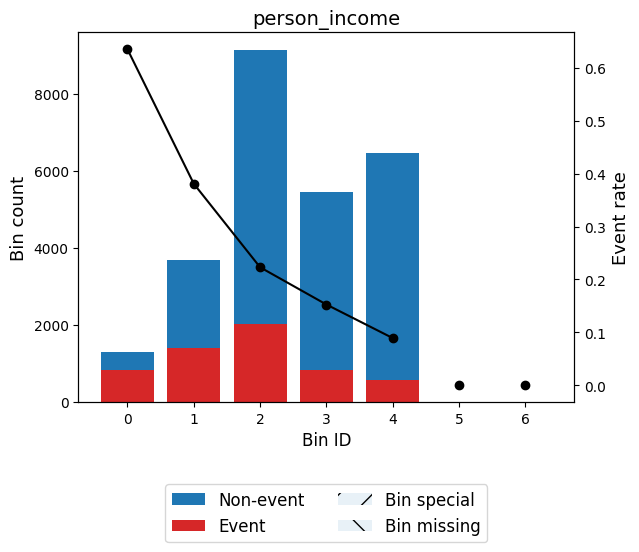

In [11]:
## GROUPEMENT VAR QUANT : L'IV mesure la capacité d’une variable à discriminer les bons et les mauvais payeurs (< 0.02 : inutile).
variable = 'person_income'
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", min_n_bins=5, max_n_bins=5)  # "cp" = solver par défaut (constraint programming)
optb.fit(dff[variable], dff['loan_status'])

bin_table = optb.binning_table.build()
# print(bin_table)
optb.binning_table.plot(metric="event_rate")

In [12]:
# loan_intent, person_home_ownership
variable = 'loan_intent'
optb = OptimalBinning(name=variable, dtype='categorical', max_n_bins=4)
optb.fit(dff[variable], dff['loan_status'])
print(optb.binning_table.build())   # voir les groupes, WoE, IV

                                                  Bin  Count  Count (%)  \
0                                           [VENTURE]   4572   0.175448   
1                                         [EDUCATION]   5160   0.198012   
2                                          [PERSONAL]   4417   0.169500   
3       [HOMEIMPROVEMENT, MEDICAL, DEBTCONSOLIDATION]  11910   0.457040   
4                                             Special      0   0.000000   
5                                             Missing      0   0.000000   
Totals                                                 26059   1.000000   

        Non-event  Event  Event rate       WoE        IV        JS  
0            3895    677    0.148075  0.473574  0.034154  0.004230  
1            4271    889    0.172287  0.293303  0.015630  0.001947  
2            3539    878    0.198777  0.117749  0.002272  0.000284  
3            8668   3242    0.272208 -0.292756  0.042364  0.005277  
4               0      0    0.000000       0.0  0.0000

In [ ]:
# ## GROUPEMENT VAR QUAL
# var = "classe_loan_intent"
# print((dff[var].value_counts())/len(dff))
# dff.groupby(dff[var])["loan_status"].mean()

In [13]:
########################### FONCTIONS POUR DISCRETISER  ##########################################################
## Variable Age
def cat_age(data:pd.DataFrame, nb_classe:int) -> pd.DataFrame:    ## Tester avec 3 et 2 classes
    if nb_classe==3:
        conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 28.50,
                  ((data["person_age"] >= 22.50) & (data["person_age"] < 28.50))             
              ]
        choix_age = ["Jeunes instables", "seniors", "Jeunes"]
        data["classe_age"] = np.select(conditions_age, choix_age, default=None)  
    elif nb_classe==2:
         conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 22.50          
              ]
         choix_age = ["Juniors", "seniors"]
         data["classe_age_2"] = np.select(conditions_age, choix_age, default=None)
    return data

def cat_income(data):
    conditions_income = [data["person_income"] < 22806.00,
                     data["person_income"] >= 79993.50,
                     (data["person_income"] >= 59853.50) & (data["person_income"] < 79993.50),
                     (data["person_income"] >= 34990.00) & (data["person_income"] < 59853.50),
                     (data["person_income"] >= 22806.00) & (data["person_income"] < 34990.00)                               
              ]
    choix_income = ["(-inf, 22806.00)", "[79993.50, inf)", "[59853.50, 79993.50)", "[34990.00, 59853.50)", "[22806.00, 34990.00)"]
    data["classe_income"] = np.select(conditions_income, choix_income, default=None) # Relation monotone décroissante
    return data

def cat_emp_length(data, nb_classe):
    if nb_classe == 5:
        conditions_emp = [data["person_emp_length"].isna(),
                  data["person_emp_length"] < 1.50,
                  data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]

        choix_emp = ["Missing","(-inf, 1.50)", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 4:
        conditions_emp = [(data["person_emp_length"].isna())|(data["person_emp_length"] < 1.50),  # 2 ème cas : je regroupe les sans_emploi et courte durée d'emploi              
                 data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]
        choix_emp = ["no_emp et < 1.50", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp_2"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_emp_length_imputed(data, nb_classe):
    if nb_classe == 4:
        conditions_emp = [data["emp_imputed"] < 2.50,
                  data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 4.50) & (data["emp_imputed"] < 7.50),
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 4.50)
              ]

        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[4.50, 7.50)", "[2.50, 4.50)"]
        data["classe_emp_imp_4"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 3:
        conditions_emp = [data["emp_imputed"] < 2.50,        
                 data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 7.50)
              ]
        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[2.50, 7.50)"]
        data["classe_emp_imp_3"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_amnt(data):
    conditions_amnt = [data["loan_amnt"] < 5012.50,
                     data["loan_amnt"] >= 18087.50,
                     (data["loan_amnt"] >= 14062.50) & (data["loan_amnt"] < 18087.50),
                     (data["loan_amnt"] >= 7487.50) & (data["loan_amnt"] < 14062.50),
                     (data["loan_amnt"] >= 5012.50) & (data["loan_amnt"] < 7487.50)                               
              ]

    choix_amnt = ["(-inf, 5012.50)", "[18087.50, inf)", "[14062.50, 18087.50)", "[7487.50, 14062.50)", "[5012.50, 7487.50)"]
    data["classe_amnt"] = np.select(conditions_amnt, choix_amnt, default=None)  # Relation en U (tester un autre regroupement si ce n'est pas significatif)
    return data

def cat_int_rate(data):
    conditions_int_rate = [data["loan_int_rate"].isna(),
                     data["loan_int_rate"] < 7.89,
                     data["loan_int_rate"] >= 15.28,
                     (data["loan_int_rate"] >= 14.37) & (data["loan_int_rate"] < 15.28),
                     (data["loan_int_rate"] >= 12.07) & (data["loan_int_rate"] < 14.37),
                     (data["loan_int_rate"] >= 7.89) & (data["loan_int_rate"] < 12.07)                               
              ]

    choix_int_rate = ["Missing","(-inf, 7.89)", "[15.28, inf)", "[14.37, 15.28)", "[12.07, 14.37)", "[7.89, 12.07)"]
    data["classe_int_rate"] = np.select(conditions_int_rate, choix_int_rate, default=None)  # Relation monotone croissante
    return data

def cat_percent_income(data):
    conditions_percent_income = [data["loan_percent_income"] < 0.16,
                     data["loan_percent_income"] >= 0.31,
                     (data["loan_percent_income"] >= 0.25) & (data["loan_percent_income"] < 0.31),
                     (data["loan_percent_income"] >= 0.16) & (data["loan_percent_income"] < 0.25)                               
              ]

    choix_percent_income = ["(-inf, 0.16)", "[0.31, inf)", "[0.25, 0.31)", "[0.16, 0.25)"]
    data["classe_percent_income"] = np.select(conditions_percent_income, choix_percent_income, default=None) # Relation monotone croissante
    return data

def cat_cred_hist_length(data):
    conditions_cred_hist = [data["cb_person_cred_hist_length"] < 2.50,
                     data["cb_person_cred_hist_length"] >= 4.50,
                     (data["cb_person_cred_hist_length"] >= 2.50) & (data["cb_person_cred_hist_length"] < 4.50)                               
              ]

    choix_cred_hist = ["(-inf, 2.50)", "[4.50, inf)", "[2.50, 4.50)"]
    data["classe_cred_hist"] = np.select(conditions_cred_hist, choix_cred_hist, default=None)
    return data


In [14]:
################ On applique les fonctions de discrétisation #######################################

## Age
dff = cat_age(dff, 3) # IV : 0.01 < 0.02 inutile dans le modèle
# dff = cat_age(dff, 2)

## Variable person_income
dff = cat_income(dff)  # IV : 0.563203

## person_emp_length
# dff = cat_emp_length(dff, 5) # IV : 0.069434
#dff = cat_emp_length(dff, 4)

## loan_amnt
dff = cat_amnt(dff) # IV : 0.085453

## loan_int_rate
dff = cat_int_rate(dff) # IV : 0.665547

## loan_percent_income
dff = cat_percent_income(dff) # IV : 0.943946

## cb_person_cred_hist_length
dff = cat_cred_hist_length(dff) # IV : 0.003482

- Imputation de la variable person_emp_length (durée d'emploi) par la médiane conditionnelle

In [15]:
# On regarde de coeff de corrélation entre person_income et person_emp_length
# L'idée c'est d'imputer la durée de travail selon les classes des revenus des individus
corr_pearson = dff["person_emp_length"].corr(dff["person_income"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.15802432271338268


In [16]:
# Calcul des médianes de durée d'emploi par bin de revenu
median_emp_by_income = dff.groupby("classe_income")["person_emp_length"].median()

# Fonction d'imputation
def impute_emp(row):
    if pd.isna(row["person_emp_length"]):
        return median_emp_by_income.loc[row["classe_income"]]
    else:
        return row["person_emp_length"]

# Appliquer l’imputation
dff["emp_imputed"] = dff.apply(impute_emp, axis=1)

In [17]:
## emp_imputed
dff = cat_emp_length_imputed(dff, 4) # IV : 0.068035
# dff = cat_emp_length_imputed(dff, 3)

- Regroupement des variables catégorielles

In [18]:
## On regroupe "loan_intent" car trop de modalité et certaines qui on quasiment le même taux de défaut
## Surtout parce que sans regrouper, on a une modalité non significative dans la régression logistique
dff.groupby("loan_intent")["loan_status"].mean()

loan_intent
DEBTCONSOLIDATION    0.285920
EDUCATION            0.172287
HOMEIMPROVEMENT      0.261005
MEDICAL              0.267092
PERSONAL             0.198777
VENTURE              0.148075
Name: loan_status, dtype: float64

In [19]:
## Les modalités "OTHER" et "RENT" ont des taux de défaut très proches, donc on les regroupe
dff.groupby("person_home_ownership")["loan_status"].mean()

person_home_ownership
MORTGAGE    0.125651
OTHER       0.305882
OWN         0.075882
RENT        0.315669
Name: loan_status, dtype: float64

In [20]:
########################### FONCTIONS DE REGROUPEMENT  ##########################################################

def cat_home_ownership(data):
    data["classe_person_home_ownership"] = np.where((data["person_home_ownership"]=='OTHER')|(data["person_home_ownership"]=='RENT'), "[OTHER, RENT]", data["person_home_ownership"])
    return data

def cat_loan_intent(data):
    data["classe_loan_intent"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL'), "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

def cat_loan_intent_2(data):
    data["classe_loan_intent_2"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL')|(data["loan_intent"]=='DEBTCONSOLIDATION'),
                                           "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

In [21]:
###########################  Application des fonctions de regroupement aux variables qualitatives ###################################
## person_home_ownership
dff = cat_home_ownership(dff)

## loan_intent
# dff = cat_loan_intent(dff) # 0.095697
dff = cat_loan_intent_2(dff)

## cb_person_default_on_file
# Pour l'instant on ne touche pas  # 0.164053

## ETUDES DES CORRELATIONS ENTRE LES VARIABLES

In [22]:
## Variables avec lesquelles on fait le régression logistique dans R (pour voir la significativité des coefficicents)
dff_reg = dff[['loan_status','classe_age','classe_income', 'classe_amnt','classe_int_rate', 'classe_percent_income', 'classe_cred_hist',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [23]:
## Calcul du V_de_Cramer et de la P_value
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    p = chi2_contingency(confusion_matrix)[1]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return [np.sqrt(chi2 / (n * (min(r, k) - 1))), p]

target = 'loan_status'
features = [col for col in dff_reg.columns if col != target]

corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
chi2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for var1 in features:
    for var2 in features:
        confusion = pd.crosstab(dff_reg[var1], dff_reg[var2])
        chi2_cramer = cramers_v(confusion)
        corr_matrix.loc[var1, var2] = chi2_cramer[0]
        chi2_matrix.loc[var1, var2] = chi2_cramer[1]

# P_value # < 0.05 (on rejette l'indépendance au seuil de 5%)
chi2_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,0.000000e+00,6.992307e-156,1.490320e-30,9.359182e-01,1.124655e-14,0.000000e+00,0.000000e+00,5.908120e-16,2.357329e-01,1.639788e-87
classe_income,6.992307e-156,0.000000e+00,0.000000e+00,1.561667e-15,0.000000e+00,9.276878e-55,0.000000e+00,0.000000e+00,4.553544e-08,2.652674e-01
classe_amnt,1.490320e-30,0.000000e+00,0.000000e+00,7.332205e-151,0.000000e+00,3.922830e-13,2.079860e-74,2.833322e-92,8.919017e-23,3.542855e-01
classe_int_rate,9.359182e-01,1.561667e-15,7.332205e-151,0.000000e+00,1.088064e-86,1.325519e-01,2.013023e-29,3.344119e-112,0.000000e+00,3.159145e-01
classe_percent_income,1.124655e-14,0.000000e+00,0.000000e+00,1.088064e-86,0.000000e+00,4.107929e-05,1.382514e-13,3.627822e-108,1.457595e-10,8.921613e-01
classe_cred_hist,0.000000e+00,9.276878e-55,3.922830e-13,1.325519e-01,4.107929e-05,0.000000e+00,2.042052e-178,2.278957e-10,3.042438e-01,1.927218e-54
classe_emp_imp_4,0.000000e+00,0.000000e+00,2.079860e-74,2.013023e-29,1.382514e-13,2.042052e-178,0.000000e+00,0.000000e+00,7.167379e-07,9.725104e-14
classe_person_home_ownership,5.908120e-16,0.000000e+00,2.833322e-92,3.344119e-112,3.627822e-108,2.278957e-10,0.000000e+00,0.000000e+00,3.134359e-24,3.319477e-64
cb_person_default_on_file,2.357329e-01,4.553544e-08,8.919017e-23,0.000000e+00,1.457595e-10,3.042438e-01,7.167379e-07,3.134359e-24,0.000000e+00,3.745711e-01
classe_loan_intent_2,1.639788e-87,2.652674e-01,3.542855e-01,3.159145e-01,8.921613e-01,1.927218e-54,9.725104e-14,3.319477e-64,3.745711e-01,0.000000e+00


In [24]:
# V_de_Cramer (>= 0.5 -> association forte)
corr_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,1.000000,0.119678,0.055433,0.009019,0.038583,0.557826,0.175518,0.038561,0.010531,0.089736
classe_income,0.119678,1.000000,0.211766,0.033360,0.194669,0.072617,0.141089,0.238330,0.039127,0.013656
classe_amnt,0.055433,0.211766,1.000000,0.086119,0.329812,0.038060,0.069932,0.092976,0.064848,0.012997
classe_int_rate,0.009019,0.033360,0.086119,1.000000,0.075980,0.016957,0.047366,0.102914,0.539444,0.014768
classe_percent_income,0.038583,0.194669,0.329812,0.075980,1.000000,0.023952,0.032058,0.099465,0.043263,0.007398
classe_cred_hist,0.557826,0.072617,0.038060,0.016957,0.023952,1.000000,0.127036,0.031269,0.009556,0.071383
classe_emp_imp_4,0.175518,0.141089,0.069932,0.047366,0.032058,0.127036,1.000000,0.181204,0.034686,0.032210
classe_person_home_ownership,0.038561,0.238330,0.092976,0.102914,0.099465,0.031269,0.181204,1.000000,0.064449,0.077268
cb_person_default_on_file,0.010531,0.039127,0.064848,0.539444,0.043263,0.009556,0.034686,0.064449,0.999868,0.010929
classe_loan_intent_2,0.089736,0.013656,0.012997,0.014768,0.007398,0.071383,0.032210,0.077268,0.010929,1.000000


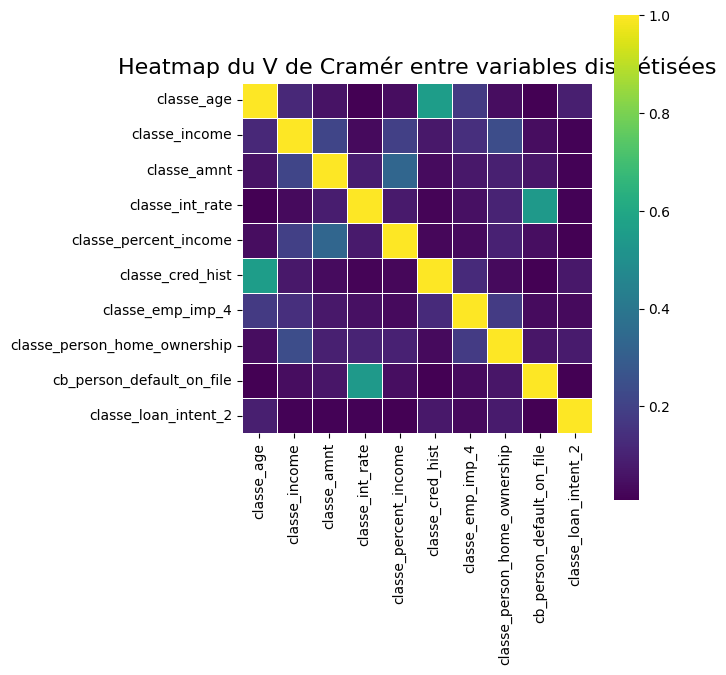

In [25]:
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix.astype(float),annot=False, cmap="viridis", square=True, linewidths=0.5)
plt.title("Heatmap du V de Cramér entre variables discrétisées", fontsize=16)
plt.tight_layout()
plt.show()

- forte association entre **classe_cred_hist** et **classe_age**
- forte association entre **cb_person_default_on_file** et **classe_int_rate**
- Association modérée entre **classe_person_income** et **classe_amnt**

In [26]:
## On remarque aussi que loan_percent_income = loan_amnt / loan_income (même s'il y'a quelques différences)
df["var"] = round(df["loan_amnt"]/df["person_income"], 2)
df[["var","loan_percent_income"]].head(10)

,var,loan_percent_income
1,0.10,0.10
2,0.57,0.57
3,0.53,0.53
4,0.64,0.55
5,0.25,0.25
6,0.45,0.45
7,0.44,0.44
8,0.42,0.42
9,0.16,0.16
10,0.41,0.41


In [27]:
corr_pearson = df["loan_percent_income"].corr(df["var"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.9992026542037479


In [28]:
results_chi2_loan_status = []
for var in features:
    confusion = pd.crosstab(dff_reg[var], dff_reg[target])
    n = confusion.sum().sum()
    r, k = confusion.shape
    chi2, p, dof, expected = chi2_contingency(confusion)
    v_cramer = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    results_chi2_loan_status.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'V_de_cramer' : v_cramer
    })
    
results_chi2_loan_status = pd.DataFrame(results_chi2_loan_status)
results_chi2_loan_status

,variable,chi2,p_value,V_de_cramer
0,classe_age,46.836383,6.754742e-11,0.042395
1,classe_income,2674.434023,0.000000e+00,0.320359
2,classe_amnt,406.505464,1.093019e-86,0.124898
3,classe_int_rate,3367.347696,0.000000e+00,0.359472
4,classe_percent_income,5040.381585,0.000000e+00,0.439798
5,classe_cred_hist,15.616729,4.063220e-04,0.024480
6,classe_emp_imp_4,307.422355,2.462054e-66,0.108615
7,classe_person_home_ownership,1521.821807,0.000000e+00,0.241659
8,cb_person_default_on_file,835.478008,1.044023e-183,0.179056
9,classe_loan_intent_2,408.978624,2.513441e-88,0.125277


- **Age** préféré à **cred_hist** *(IV_age > IV_cred_hist)*
- **loan_int_rate** préféré à **cb_person_default_on_file** *(IV_rate > IV_default_on_file)*

In [51]:
# Exportation de la table pour l'utiliser dans R (On fait la regression logistique sur R pour 
## voir clairement la significativité des variables)
dff_reg.to_csv("F:/personnel/MOSEF Sorbonne/Cours/Modélisation risque de crédit et scoring/df_reg.csv", sep=",", index=False, encoding="utf-8")

#### MODELISATION : Régression Logistique

In [29]:
# Variables retenues pour le modèle
dff_reg = dff[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [ ]:
## Base à utiliser pour le suite
# dff_reg.to_csv("../data/data.csv", sep=",", index=False, encoding="utf-8")

In [30]:
print(len(df))
len(df_test_set) + len(dff_reg)

32574


32574

In [31]:
dff_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26059 entries, 20061 to 18759
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   loan_status                   26059 non-null  int64 
 1   classe_income                 26059 non-null  object
 2   classe_int_rate               26059 non-null  object
 3   classe_percent_income         26059 non-null  object
 4   classe_emp_imp_4              26059 non-null  object
 5   classe_person_home_ownership  26059 non-null  object
 6   cb_person_default_on_file     26059 non-null  object
 7   classe_loan_intent_2          26059 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.8+ MB


In [32]:
features = dff_reg.select_dtypes(include=['object']).columns
target = "loan_status"
X = dff_reg[features]
y = dff_reg[target]

In [33]:
## VOIR LES COEFS
cat_vars = X.columns.tolist()

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_final = pd.DataFrame(ohe.fit_transform(X[cat_vars]), columns=ohe.get_feature_names_out(cat_vars), index=X.index)

# Ajouter constante pour statsmodels
X_final = sm.add_constant(X_final)

# =============================
# 3. Fit régression logistique
# =============================
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()

# =============================
# 4. Résultats : coefficients, p-values, odds ratio
# =============================
summary_df = pd.DataFrame({
    'variable': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues,
    'odds_ratio': result.params.apply(lambda x: round(np.exp(x), 3))
}).sort_values(by='coefficient', ascending=False)

summary_df

Optimization terminated successfully.
         Current function value: 0.325918
         Iterations 7


,variable,coefficient,p_value,odds_ratio
"classe_int_rate_[15.28, inf)","classe_int_rate_[15.28, inf)",3.129853,0.000000e+00,22.871
"classe_percent_income_[0.31, inf)","classe_percent_income_[0.31, inf)",3.077106,0.000000e+00,21.696
"classe_int_rate_[14.37, 15.28)","classe_int_rate_[14.37, 15.28)",2.399116,3.420801e-154,11.013
classe_int_rate_Missing,classe_int_rate_Missing,0.889905,3.206044e-26,2.435
"classe_int_rate_[12.07, 14.37)","classe_int_rate_[12.07, 14.37)",0.888796,1.953306e-33,2.432
"classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]","classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]",0.854369,1.592423e-54,2.350
"classe_person_home_ownership_[OTHER, RENT]","classe_person_home_ownership_[OTHER, RENT]",0.817229,1.033279e-70,2.264
"classe_int_rate_[7.89, 12.07)","classe_int_rate_[7.89, 12.07)",0.439532,6.030602e-11,1.552
"classe_percent_income_[0.25, 0.31)","classe_percent_income_[0.25, 0.31)",0.391787,1.252897e-09,1.480
"classe_percent_income_[0.16, 0.25)","classe_percent_income_[0.16, 0.25)",0.257645,1.104699e-07,1.294


In [62]:
## Validation croisée
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import cross_val_predict
cat_vars = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_vars)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42))
])
y_train_pred = cross_val_predict(model, X, y, cv=3, method='predict_proba')[:, 1]


In [73]:
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y, y_train_pred)
# print(f'Précision : {precision_score(y, y_train_pred)}')
# print(f'Recall : {recall_score(y, y_train_pred)}')
# print(f'f1_score : {f1_score(y, y_train_pred)}')
print(f'roc_auc_score : {roc_auc_score(y, y_train_pred)}')
# print(f'balanced_accuracy_score : {balanced_accuracy_score(y, y_train_pred)}')

# cm
# ligne : classe réelle; colonne : classe prédite

roc_auc_score : 0.8806689897498878


- On prédit sur le Test_set

In [64]:
thresholds = np.linspace(0.01, 0.99, 50)
results = []
for th in thresholds:
    y_pred = (y_train_pred >= th).astype(int)

    results.append({
        "threshold": th,
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred)
    })

df_results = pd.DataFrame(results)


In [76]:
# plt.plot(df_results.threshold, df_results.precision, label="Precision")
# plt.plot(df_results.threshold, df_results.recall, label="Recall")
# plt.plot(df_results.threshold, df_results.f1, label="F1")
# plt.plot(df_results.threshold, df_results.balanced_accuracy, label="Balanced Accuracy")

# plt.xlabel("Seuil")
# plt.ylabel("Score")
# plt.legend()
# plt.grid(True)
# plt.show()

In [79]:
# meilleur seuil pour la balance accuracy
best_bal_acc = df_results.loc[df_results.balanced_accuracy.idxmax()]
print("Meilleur seuil (Balanced Acc):", best_bal_acc.threshold)
print(best_bal_acc)

Meilleur seuil (Balanced Acc): 0.53
threshold            0.530000
precision            0.597997
recall               0.756068
f1                   0.667806
balanced_accuracy    0.807107
Name: 26, dtype: float64


- On va considérer le seuil 0.50

In [ ]:
test = df_test_set.copy()
# test.to_csv("../data/test_set.csv", sep=",", index=False, encoding="utf-8")

In [ ]:
## On applique toute les transformation du train_set au test_set
test = cat_age(test, 3) 
test = cat_income(test)  
test = cat_amnt(test)
test = cat_int_rate(test) 
test = cat_percent_income(test)
test = cat_cred_hist_length(test)
test = cat_home_ownership(test)
test = cat_loan_intent_2(test)

test["emp_imputed"] = test.apply(impute_emp, axis=1)

test = cat_emp_length_imputed(test, 4)

test_reg = test[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [ ]:
X_test = test_reg[features]
y_test = test_reg[target]
model.fit(X, y)
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)
y_train_proba = model.predict_proba(X)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)

In [ ]:
## Performance sur le Train_set
print("Balanced Accuracy :", balanced_accuracy_score(y, y_train_pred))
print("Precision :", precision_score(y, y_train_pred))
print("Recall :", recall_score(y, y_train_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y, y_train_pred))
print("ROC AUC :", roc_auc_score(y, y_train_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y, y_train_pred))

Balanced Accuracy : 0.806709143727312
Precision : 0.577892098667722
Recall : 0.7704889201547661
F1-score : 0.6604356674455416
ROC AUC : 0.8816903476853828

Confusion Matrix :
[[17173  3200]
 [ 1305  4381]]


In [ ]:
## Performance sur le Test_set
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision :", precision_score(y_test, y_test_pred))
print("Recall :", recall_score(y_test, y_test_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y_test, y_test_pred))
print("ROC AUC :", roc_auc_score(y_test, y_test_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_test_pred))

Balanced Accuracy : 0.8079295037945319
Precision : 0.5832443970117396
Recall : 0.7691766361717101
F1-score : 0.6634294385432473
ROC AUC : 0.8868945734339388

Confusion Matrix :
[[4313  781]
 [ 328 1093]]


- Gini ≈ 0.77 (calcul rapide : 2 * AUC - 1) ce qui signifie un bon pouvoir de discrimination.

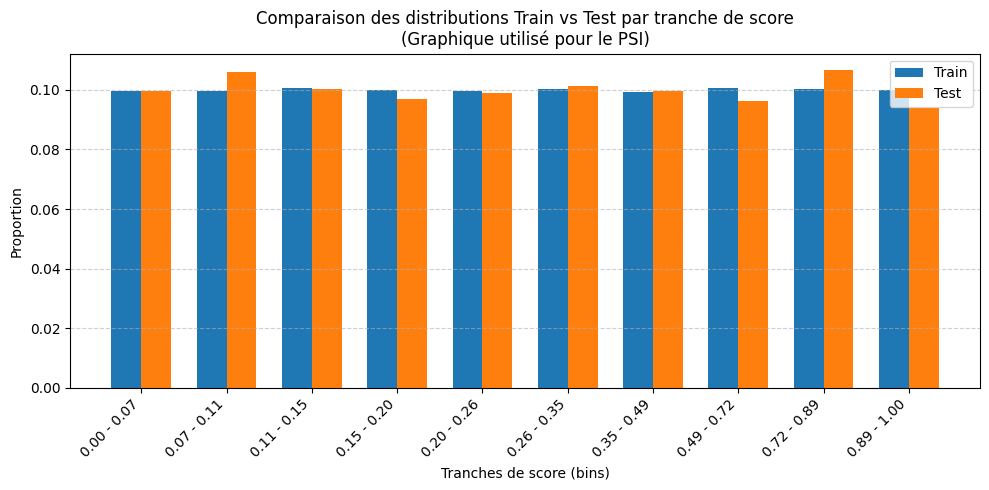

PSI score : 0.0015330817123569355


In [99]:
## Calcul du PSI : Il mesure la stabilité des scores (probabilités) entre Train  (période d’entraînement) et Test (nouvelle population que tu veux valider)
def plot_psi_chart(train_proba, test_proba, bins=10):
    # 1. Créer les bins selon les percentiles du train
    breakpoints = np.percentile(train_proba, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    # 2. Calculer les distributions
    train_counts, _ = np.histogram(train_proba, bins=breakpoints)
    test_counts, _ = np.histogram(test_proba, bins=breakpoints)

    train_perc = train_counts / len(train_proba)
    test_perc = test_counts / len(test_proba)

    # Pour affichage
    bin_labels = []
    for i in range(len(breakpoints) - 1):
        bin_labels.append(f"{breakpoints[i]:.2f} - {breakpoints[i+1]:.2f}")

    x = np.arange(len(train_perc))  # positions des bins
    width = 0.35

    # 3. Tracé du graphique
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, train_perc, width, label='Train')
    plt.bar(x + width/2, test_perc, width, label='Test')

    plt.xticks(x, bin_labels, rotation=45, ha='right')
    plt.ylabel("Proportion")
    plt.xlabel("Tranches de score (bins)")
    plt.title("Comparaison des distributions Train vs Test par tranche de score\n(Graphique utilisé pour le PSI)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Utilisation ---
plot_psi_chart(y_train_proba, y_test_proba, bins=10)


def calculate_psi(expected, actual, bins=10):
    # Découpage selon les percentiles de la population train ("expected")
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins+1))
    breakpoints = np.unique(breakpoints)  # éviter les bins identiques

    # Histogrammes
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    # Convertir en proportions
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Éviter division par zéro
    expected_perc = np.where(expected_perc == 0, 1e-8, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-8, actual_perc)

    # PSI
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi

psi_value = calculate_psi(y_train_proba, y_test_proba, bins=10)
print("PSI score :", psi_value)

- Population stable (PSI < 0.1)

#### Scorecard Bancaire

Une scorecard bancaire transforme les probabilités prédites par le modèle en points (souvent 0–1000) pour :

- faciliter la lecture par les analystes métiers

- intégrer un cadre réglementaire (Bâle II/III)

- comparer différents clients sur une échelle commune

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 115485 stored elements and shape (26059, 21)>